In [3]:
import numpy as np
import pandas as pd
import scipy.stats as ss

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt

In [4]:
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
customers = pd.read_csv('olist_customers_dataset.csv')

In [5]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [6]:
items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [7]:
customers

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


# Задача 1. Оценить месячный retention в оформление заказа с помощью когортного анализа.

На первом этапе вы решили посмотреть на метрики маркетплейса и на возвращаемость клиента в продукт.

Для этого вам нужно:

Оценить месячный retention в оформление заказа с помощью когортного анализа, так как важно, чтобы клиенты возвращались в маркетплейс для совершения больших покупок.

В рамках исследования необходимо:

    Исследовать датасет и определить, какой вид заказа будет учитываться в retention 

    Построить месячный retention 

    Проанализировать, чему равен медианный retention 1-го месяца (т.е. взять retention 1-ого месяца для всех когорт и посчитать по этим числам медиану)

    Найти когорту с самым высоким retention на 3-й месяц.
    Проиллюстрировать результаты релевантной визуализацией, удобной для восприятия.

В условии указано: "важно, чтобы клиенты возвращались в маркетплейс для совершения больших покупок." Для расчета retention используем доставленные заказы только со статусом delivered.

In [8]:
# Преобразуем дату покупки в datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Оставляем только доставленные заказы
delivered = orders[orders['order_status'] == 'delivered'].copy()

# Объединяем с таблицей клиентов
df = delivered.merge(customers, on='customer_id', how='left')

# Определяем когорту
first_orders = df.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
# Для расчетов
first_orders['cohort_year'] = first_orders['order_purchase_timestamp'].dt.year
first_orders['cohort_month'] = first_orders['order_purchase_timestamp'].dt.month
# Для простоты понимания
first_orders['cohort_label'] = first_orders['order_purchase_timestamp'].dt.to_period('M')

# Присоединяем когортные данные к заказам
df = df.merge(
    first_orders[['customer_unique_id', 'cohort_year', 'cohort_month', 'cohort_label']],
    on='customer_unique_id',
    how='left'
)

# Вычисляем период (число месяцев между этим заказом и первым заказом клиента)
df['period'] = (df['order_purchase_timestamp'].dt.year - df['cohort_year']) * 12 + (df['order_purchase_timestamp'].dt.month - df['cohort_month'])

# Группируем по двум параметрам: и по названию когороты и по периоду между первой и текущей покупкой для формирования когорт
cohort_data = df.groupby(['cohort_label', 'period'])['customer_unique_id'].nunique().reset_index()
# Переименуем столб customer_unique_id для простоты восприятия
cohort_data.columns = ['cohort_label', 'period', 'users']

# Считаем размер когорты и переименовываем столбы для понятности
cohort_sizes = cohort_data[cohort_data['period'] == 0][['cohort_label', 'users']].rename(columns={'users': 'cohort_size'})
# Добавляем размеры когорт
cohort_data = cohort_data.merge(cohort_sizes, on='cohort_label', how='left')
# Считаем 
cohort_data['retention'] = cohort_data['users'] / cohort_data['cohort_size']

# Перестраиваем таблицу к понятному виду
pivot = cohort_data.pivot(index='cohort_label', columns='period', values='retention')

# Медианный retention на 1-й месяц, для когорт 2016-09 и 2016-10 считаем значения как "0", а остальные убираем

retention_1_custom = pivot[1].copy()
# заменяем NaN на 0 у 2016-09 и 2016-10
cohorts_to_fill = ['2016-09', '2016-10']
for cohort in cohorts_to_fill:
    if cohort in retention_1_custom.index and pd.isna(retention_1_custom[cohort]):
        retention_1_custom[cohort] = 0.0

# Остальные NaN удаляем (они не участвуют в расчёте)
retention_1_custom = retention_1_custom.dropna()
median_1_custom = retention_1_custom.median()
print(f'Медианный retention на 1-й месяц : {median_1_custom:.2%}')





Медианный retention на 1-й месяц : 0.48%


In [29]:
orders[orders['order_status'] == 'canceled']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
397,1b9ecfe83cdc259250e1a8aca174f0ad,6d6b50b66d79f80827b6d96751528d30,canceled,2018-08-04 14:29:27,2018-08-07 04:10:26,NaN,NaT,2018-08-14
613,714fb133a6730ab81fa1d3c1b2007291,e3fe72696c4713d64d3c10afe71e75ed,canceled,2018-01-26 21:34:08,2018-01-26 21:58:39,2018-01-29 22:33:25,NaT,2018-02-22
1058,3a129877493c8189c59c60eb71d97c29,0913cdce793684e52bbfac69d87e91fd,canceled,2018-01-25 13:34:24,2018-01-25 13:50:20,2018-01-26 21:42:18,NaT,2018-02-23
1130,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,NaN,NaN,NaT,2018-09-12
1801,ed3efbd3a87bea76c2812c66a0b32219,191984a8ba4cbb2145acb4fe35b69664,canceled,2018-09-20 13:54:16,NaN,NaN,NaT,2018-10-17
...,...,...,...,...,...,...,...,...
98791,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaN,NaT,2017-03-30
98909,e49e7ce1471b4693482d40c2bd3ad196,e4e7ab3f449aeb401f0216f86c2104db,canceled,2018-08-07 11:16:28,NaN,NaN,NaT,2018-08-10
99143,6560fb10610771449cb0463c5ba12199,0d07d0a588caf93cc66b7a8aff86d2fe,canceled,2017-10-01 22:26:25,2017-10-01 22:35:22,NaN,NaT,2017-10-27
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaT,2018-10-01


In [27]:
orders.order_status.unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [10]:
cohort_sizes

,cohort_label,cohort_size
0,2016-09,1
1,2016-10,262
10,2016-12,1
12,2017-01,717
30,2017-02,1628
48,2017-03,2503
66,2017-04,2256
83,2017-05,3451
99,2017-06,3037
114,2017-07,3752


In [11]:
median_1_custom 

0.004787710958260656

In [12]:
retention_3 = pivot[3].dropna()
max_cohort = retention_3.idxmax()
max_value = retention_3.max()
print(f'Когорта с самым высоким retention на 3-й месяц: {max_cohort} ({max_value:.2%})')

Когорта с самым высоким retention на 3-й месяц: 2017-06 (0.43%)


In [13]:
pivot

period,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_label,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.007634
2016-12,1.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,0.002789,0.001395,0.004184,0.001395,0.004184,0.001395,0.001395,NaN,0.004184,0.001395,0.006974,0.004184,0.001395,0.001395,0.002789,0.004184,0.001395,NaN
2017-02,1.0,0.001843,0.003071,0.001229,0.004300,0.001229,0.002457,0.001843,0.001229,0.001843,0.001229,0.003071,0.001229,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN
2017-03,1.0,0.004395,0.003596,0.003995,0.003596,0.001598,0.001598,0.003196,0.003196,0.000799,0.003596,0.001199,0.001998,0.001199,0.001598,0.002397,0.000799,0.001199,NaN,NaN
2017-04,1.0,0.006206,0.002216,0.001773,0.002660,0.002660,0.003546,0.003103,0.003103,0.001773,0.002660,0.000887,0.000443,0.000443,0.000887,0.000887,0.001330,NaN,NaN,NaN
2017-05,1.0,0.004636,0.004636,0.002898,0.002898,0.003187,0.004057,0.001449,0.002608,0.002608,0.002608,0.003477,0.002318,0.000290,0.001739,0.002028,NaN,NaN,NaN,NaN
2017-06,1.0,0.004939,0.003951,0.004281,0.002963,0.003951,0.003622,0.002305,0.001317,0.001976,0.002963,0.003622,0.001646,0.001646,0.002305,NaN,NaN,NaN,NaN,NaN


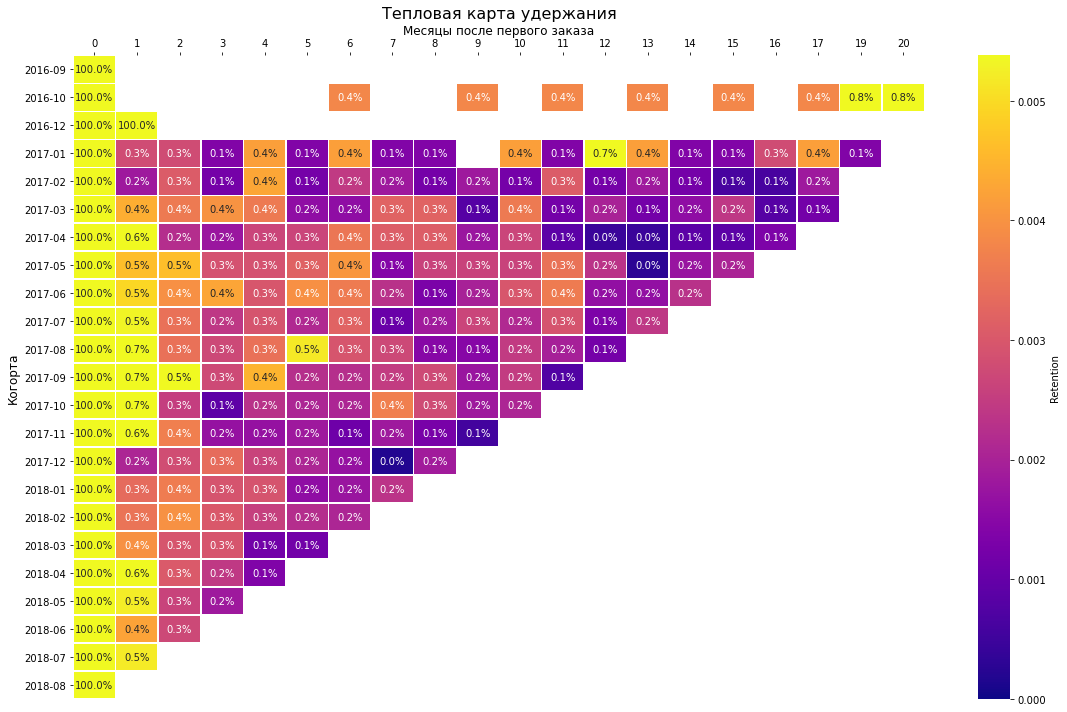

In [14]:
pivot.columns = pivot.columns.astype(int)

#Тепловая карта

max_period = min(pivot.columns.max(), 24)
pivot = pivot.loc[:, :max_period]


# Вычисляем верхнюю границу цветовой шкалы (исключаем период 0)
# Берём 95-й процентиль всех значений retention (кроме 0 и 1)
values = pivot.values.flatten()
values = values[~np.isnan(values)]
# Исключаем 0 и 1, чтобы vmax не был завышен
values = values[(values > 0) & (values < 1)]
if len(values) > 0:
    vmax = np.percentile(values, 95)   # например, 0.15-0.3
else:
    vmax = 0.3  # запасное значение

#Построение тепловой карты
plt.figure(figsize=(16, 10))
ax = sns.heatmap(
    pivot,
    annot=True,
    fmt='.1%',                # один знак после запятой
    cmap='plasma',            # яркая контрастная палитра
    cbar_kws={'label': 'Retention'},
    linewidths=0.5,
    linecolor='white',
    vmin=0,
    vmax=vmax                 # период 0 (100%) будет белым, остальные – в цвете
)

# Перемещаем ось X наверх
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# Оформление
plt.title('Тепловая карта удержания', fontsize=16)
plt.xlabel('Месяцы после первого заказа', fontsize=12)
plt.ylabel('Когорта', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


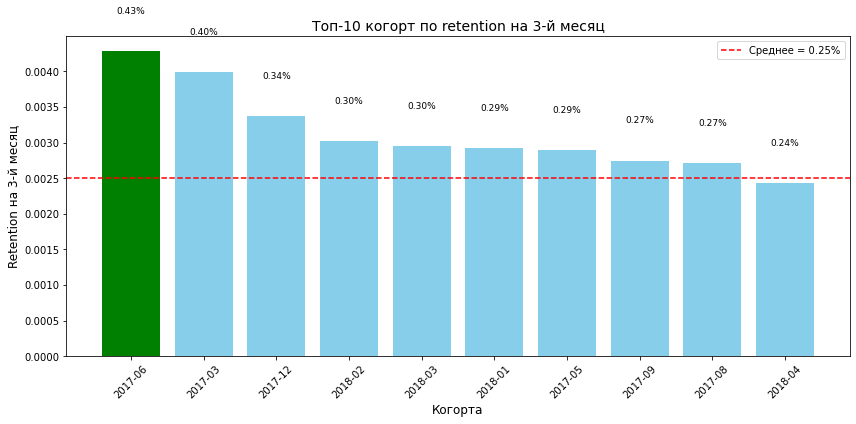

Когорта с самым высоким retention на 3-й месяц: 2017-06 (0.43%)


In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Преобразуем индекс pivot в строки (чтобы избежать ошибок с Period)
pivot_plot = pivot.copy()
pivot_plot.index = pivot_plot.index.astype(str)

# Данные для 3-го месяца
ret_3 = pivot_plot[3].dropna().sort_values(ascending=False)
top10 = ret_3.head(10)                      # топ-10 когорт
leader = top10.index[0]                     # когорта-лидер
max_val = top10.iloc[0]                     # значение лидера

# Построение столбчатой диаграммы
plt.figure(figsize=(12, 6))

# Цвета: для лидера – зелёный, для остальных – синий
colors = ['green' if c == leader else 'skyblue' for c in top10.index]
bars = plt.bar(top10.index, top10.values, color=colors)

# Средняя линия
mean_ret_3 = ret_3.mean()
plt.axhline(y=mean_ret_3, color='red', linestyle='--', 
            label=f'Среднее = {mean_ret_3:.2%}')

# Подписи значений на столбцах
for bar, val in zip(bars, top10.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.0005, 
             f'{val:.2%}', ha='center', va='bottom', fontsize=9)

# Оформление
plt.title('Топ-10 когорт по retention на 3-й месяц', fontsize=14)
plt.xlabel('Когорта', fontsize=12)
plt.ylabel('Retention на 3-й месяц', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Вывод числового результата
print(f'Когорта с самым высоким retention на 3-й месяц: {leader} ({max_val:.2%})')

# Задача 2. Определить, существует ли product/market fit у маркетплейса.

Построив retention, вы решили оценить, насколько хорошо продукт закрывает потребности клиента.

Для этого вам нужно:

Определить, существует ли product/market fit у этого маркетплейса. Ведь до сих пор непонятно, можно ли масштабировать подобный продукт на новые рынки. Есть вероятность, что маркетплейс будет приносить убытки.

В рамках исследования необходимо:

    Оценить наличие product/market fit у данного продукта с помощью когортного анализа, полученного на предыдущем шаге.

    Пояснить свою позицию и сформулировать, на чём маркетплейс должен сконцентрироваться в ближайшее время. Если PMF есть, то в какую сторону лучше развивать продукт дальше? Если PMF нет, то какие причины могут быть у этого?
    Подкрепить свои выводы релевантной визуализацией, удобной для восприятия.

PMF возникает, когда продукт удовлетворяет потребности конкретного сегмента аудитории, создает достаточную добавочную ценность, в следствие чего пользователи РЕГУЛЯРНО выбирают его для решения своей задачи. 
Судя по хитмапу выше и столбчатой диаграмме ниже, удержание крайне низкое - в среднем менее 0,5% уже в первом месяце. Из 1000 новых клиентов в следующем месяце возвращается 5 человек, удержания нет. Это не соответствует признакам PMF для обычного маркетплейса, который предлагает бытовые товары, а не товары длительного пользования (мебель или автомобили). По условию наш маркетплейс занимается продажей новых товаров из Бразилии. Бразилия известна своим кофе, но не автомобилями или электронной техникой. 

Продукт с низким PMF называют “дырявым ведром”, так как пользователи утекают и не задерживаются в продукте. То есть они не находят для себя ценности в продукте, не покупают его и не приносят нам прибыль.

Если продукт — “дырявое ведро”, то масштабировать его нельзя, потому что пользователи не будут задерживаться в продукте. MAU будет расти, пока мы тратим деньги на привлечение, но со временем рост остановится, так как количество новых и уходящих пользователей сравняется. Когда деньги на привлечение иссякнут, из-за низкой удерживаемости и слабой конверсии в платящих клиентов аудитория сократится, и продукт перестанет существовать.
Поэтому нужно не масштабироваться, а найти причину низкого удержания и устранить ее. 
Возможные причины низкого PMF:
-Маленький ассортимент
-Дорогие товары
-Неудобный интерфейс
-Ограниченная доставка
-Слабая работа поддержки
-Дорогая доставка
-Алгоритмы не показывают клиенту релевантные товары
-Нет конкурентного преимущества
-Непривлекательный дизайн
-Низкое качество предлагаемых товаров


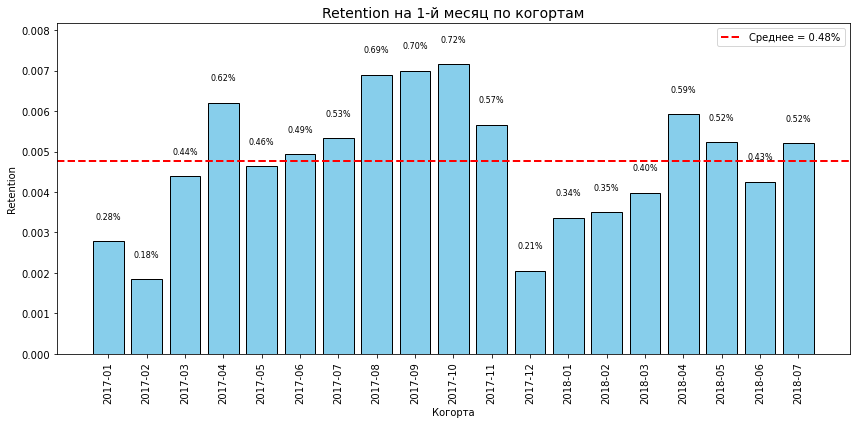

In [16]:

# Подготовка данных
pivot_plot = pivot.copy()
pivot_plot.index = pivot_plot.index.astype(str)
pivot_plot = pivot_plot.sort_index()

# Берём только 1-й месяц
ret_1 = pivot_plot[1].dropna()

# Когорта 2016-12 состоит из одного покупателя, уберём ее для наглядности. 
if '2016-12' in ret_1.index:
    ret_1 = ret_1.drop('2016-12')

# Вычисляем среднее для наглядности
mean_1 = ret_1.mean()

# Вертикальная столбчатая диаграмма
plt.figure(figsize=(12, 6))
bars = plt.bar(ret_1.index, ret_1.values, color='skyblue', edgecolor='black')

# Увеличиваем верхнюю границу оси Y, чтобы подписи помещались
max_val = ret_1.max()
plt.ylim(0, max_val * 1.14)

# Подписи значений на столбцах
for bar, val in zip(bars, ret_1.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.0005,
             f'{val:.2%}', ha='center', va='bottom', fontsize=8)

# Линии среднего 
plt.axhline(y=mean_1, color='red', linestyle='--', linewidth=2,
            label=f'Среднее = {mean_1:.2%}')


# Оформление
plt.title('Retention на 1-й месяц по когортам', fontsize=14)
plt.xlabel('Когорта')
plt.ylabel('Retention')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

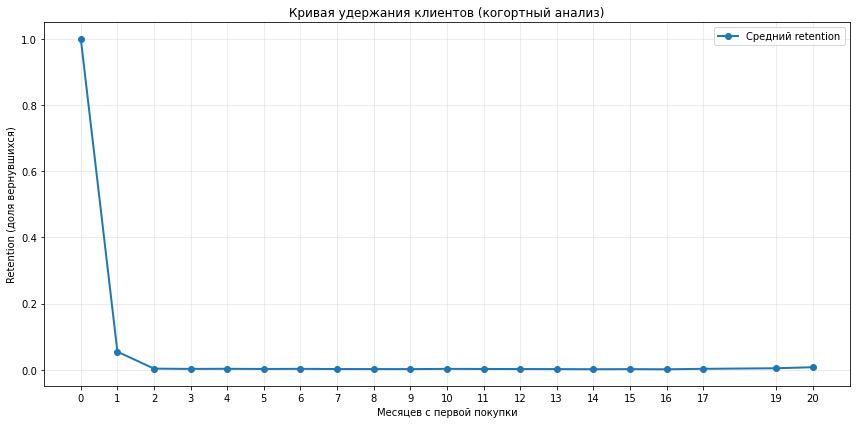

In [17]:
# Усредняем retention по всем когортам для каждого периода
avg_retention = pivot.mean(axis=0)   # среднее по когортам для каждого месяца
med_retention = pivot.median(axis=0) # медианное

# Построение графика
plt.figure(figsize=(12, 6))

# Средняя кривая удержания
plt.plot(avg_retention.index, avg_retention.values, 
         marker='o', linewidth=2, label='Средний retention')

# Настройки осей и заголовка
plt.xlabel('Месяцев с первой покупки')
plt.ylabel('Retention (доля вернувшихся)')
plt.title('Кривая удержания клиентов (когортный анализ)')
plt.legend()
plt.grid(True, alpha=0.3)

# Подписываем каждый месяц
plt.xticks(avg_retention.index)

plt.tight_layout()
plt.show()

График показывает драматическое падение удержания уже с первого месяца

# Задача 3. Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

Вы разобрались с наличием product/market fit. Теперь вас просят сформулировать продуктовые метрики маркетплейса, чтобы компания могла на них ориентироваться.

В первую очередь необходимо:

Определить 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.

    Первая метрика должна отражать рост объёма продаж маркетплейса.

    Вторая — показывать объем аудитории, которой продукт доставляет ценность.

    Третья — отражать заинтересованность новых клиентов в продукте (даже если вы не можете посчитать ее на имеющихся у вас данных).

    Четвёртая — отражать вовлеченность клиента в продолжение использования продукта.

    Пятая — отражать денежное выражение вовлеченности клиента.

Визуализируйте первую, вторую, четвёртую и пятую метрики. Используйте месячную гранулярность и окно в 1 месяц, если это нужно. 

Я выбрал 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании. Они охватывают главные аспекты жизнедеятельности маркетплейса и выстраиваются в логичную систему. 


Первая метрика: Общий объём продаж. Сумма стоимости всех заказов в неделю/месяц/квартал/год
Эта метрика напрямую отвечает за контроль масштаба бизнеса и динамику роста продаж. Так как ваш продакт-менеджер Петя переживает из-за стагнации выручки, GMV покажет верхнеуровневый финансовый результат. Эту метрику можно декомпозировать на другие факторы.  Изменение этого показателя сразу сигнализирует о том, растет ли бизнес физически, хотя само по себе оно не раскрывает детальных причин изменений.

Вторая метрика: MAU - Monthly Active Buyers  - Ежемесячные активные покупатели 
Количество уникальных пользователей, совершивших заказ в данном месяце.Показывает размер активной покупательской аудитории за месяц. Данная метрика помогает оценивать, насколько маркетплейс вовлекает аудиторию и создает привычку совершать покупки регулярно. Стабильный объем или рост MAU будет говорить о том, что платформа удерживает интерес клиентов.



Третья метрика: Конверсия новых посетителей в покупатели. Количество новых покупателей делить на количество новых пользователей. Если новый пользователь приходит на сайт и быстро совершает покупку, значит, интерфейс понятен, товары вызывают интерес, а добавочная ценность очевидна с первого визита. Низкая конверсия — первый признак проблем с активацией пользователей и соответствием продукта ожиданиям.

Четвёртая метрика: Частота покупок. Среднее количество заказов на одного активного клиента за день/месяц/год. Это маркер хорошего retention: довольный покупатель совершает повторные покупки, подтверждая наличие Product-Market Fit.

Пятая метрика: ARPU – Average Revenue Per User - средний доход на одного пользователя - средний доход, который приносит один активный пользователь за конкретный день/месяц/год. Позволяет понять, сколько в среднем приносит один привлеченный на платформу пользователь. Это помогает следить за тем, чтобы юнит-экономика оставалась здоровой при масштабировании, а привлечение пользователей окупалось.

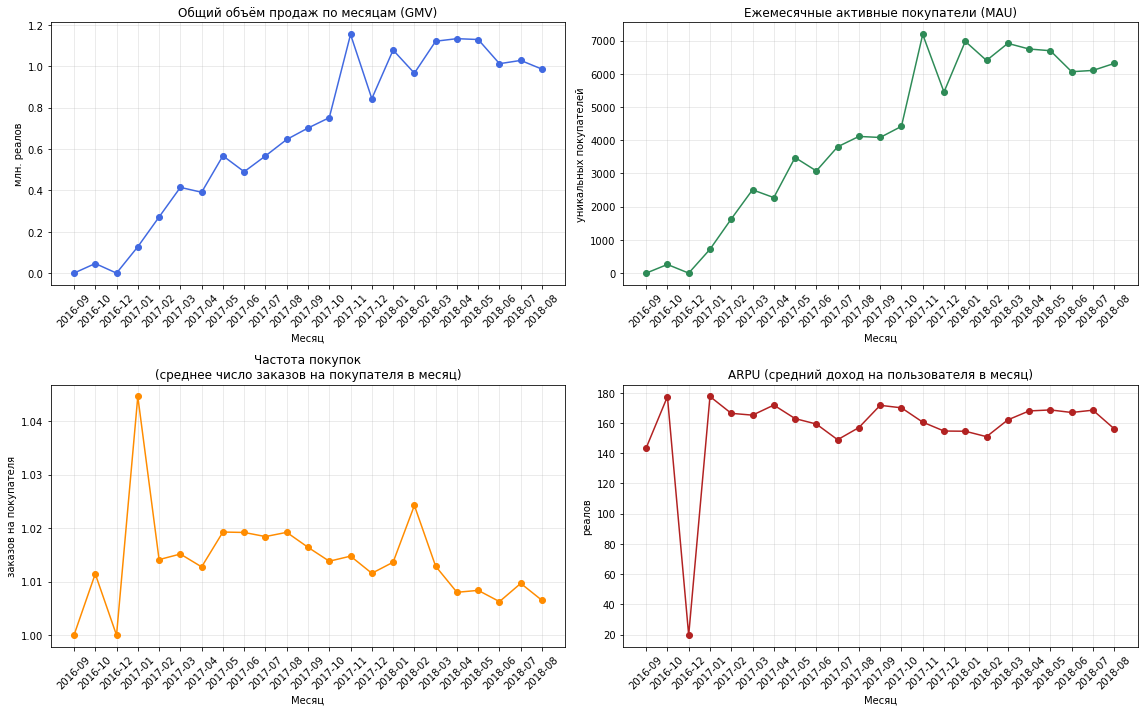

In [18]:
# Прописываем еще раз
delivered = orders[orders['order_status'] == 'delivered'].copy()
# полная стоимость заказа = цена + стоимость доставки
items['order_value'] = items['price'] + items['freight_value']
order_values = items.groupby('order_id')['order_value'].sum().reset_index()
delivered = delivered.merge(order_values, on='order_id', how='left')
# Добавляем уникальных клиентов
delivered = delivered.merge(customers[['customer_id', 'customer_unique_id']],
                            on='customer_id', how='left')
# Период = месяц
delivered['order_month'] = delivered['order_purchase_timestamp'].dt.to_period('M')

# Считаем метрики:общий объём продаж, MAU, кол-во заказов
monthly = delivered.groupby('order_month').agg(
    total_revenue=('order_value', 'sum'),
    active_buyers=('customer_unique_id', 'nunique'),
    total_orders=('order_id', 'count')
).reset_index()

# Четвёртая метрика: частота покупок (среднее число заказов на активного покупателя)
monthly['purchase_frequency'] = monthly['total_orders'] / monthly['active_buyers']

# Пятая метрика: ARPU (средний доход на пользователя)
monthly['arpu'] = monthly['total_revenue'] / monthly['active_buyers']

# Подготовка для визуализации 
monthly = monthly.sort_values('order_month')
monthly['order_month_str'] = monthly['order_month'].astype(str)

# Визуализация

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# График 1. Общий объём продаж
axes[0].plot(monthly['order_month_str'], monthly['total_revenue'] / 1e6,
             marker='o', color='royalblue')
axes[0].set_title('Общий объём продаж по месяцам (GMV)')
axes[0].set_ylabel('млн. реалов')
axes[0].tick_params(axis='x', rotation=45)

# График 2. MAU
axes[1].plot(monthly['order_month_str'], monthly['active_buyers'],
             marker='o', color='seagreen')
axes[1].set_title('Ежемесячные активные покупатели (MAU)')
axes[1].set_ylabel('уникальных покупателей')
axes[1].tick_params(axis='x', rotation=45)

# График 3. Частота покупок
axes[2].plot(monthly['order_month_str'], monthly['purchase_frequency'],
             marker='o', color='darkorange')
axes[2].set_title('Частота покупок\n(среднее число заказов на покупателя в месяц)')
axes[2].set_ylabel('заказов на покупателя')
axes[2].tick_params(axis='x', rotation=45)

# График 4. ARPU
axes[3].plot(monthly['order_month_str'], monthly['arpu'],
             marker='o', color='firebrick')
axes[3].set_title('ARPU (средний доход на пользователя в месяц)')
axes[3].set_ylabel('реалов')
axes[3].tick_params(axis='x', rotation=45)

for ax in axes:
    ax.set_xlabel('Месяц')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Задача 4. Выбрать одну из 3 основных гипотез с помощью фреймворка ICE.

Посмотрев с продактом на когортный анализ и метрики, вы решили, что нужно изменить продукт. Метрики необходимо срочно повышать. Вместе с командой вы сформулировали 3 гипотезы, в которые вы верите. По каждой гипотезе команда заполнила показатели по Ease, Confidence. Вам нужно заполнить самый важный показатель — Impact. Для этого вам требуется:

Выбрать одну из трёх основных гипотез с помощью фреймворка ICE, которые были сформированы продактом и, кажется, должны улучшить пользовательский опыт в маркетплейсе.

Для расчёта Impact возьмите данные с июня 2017 года. Считайте, что конверсия в повторный заказ равна величине медианного retention 1-го месяца (см. пункт 1 проекта).


In [19]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [20]:
# Даты
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Данные с июня 2017
since_jun = orders[orders['order_purchase_timestamp'] >= '2017-06-01'].copy()



# Гипотеза 1: убираем все отмены = Количество отменённых заказов с июня 2017
canceled_orders = since_jun[since_jun['order_status'] == 'canceled']
new_delivered_total = len(canceled_orders)        # столько заказов станут delivered


# Гипотеза 2: убираем опоздания, конверсия в повторный 0.48%
#Только доставленные заказы
delivered = since_jun[since_jun['order_status'] == 'delivered']
# Заказы с опозданием
late = delivered[
    delivered['order_delivered_customer_date'] > 
    delivered['order_estimated_delivery_date']
]

# Дополнительные заказы за счёт устранения опозданий
extra_orders_total = len(late) * 0.0048


delivered = since_jun[since_jun['order_status'] == 'delivered']
late = delivered[delivered['order_delivered_customer_date'] > 
                 delivered['order_estimated_delivery_date']]
extra_orders2 = len(late) * 0.0048

# Гипотеза 3: клиенты с единственным заказом, конверсия 0.48%
# Объединяем заказы и клиентов
orders_cust = orders.merge(customers[['customer_id', 'customer_unique_id']], 
                           on='customer_id', how='left')

# Считаем статистику по каждому уникальному клиенту
cust_stats = orders_cust.groupby('customer_unique_id').agg(
    first_order=('order_purchase_timestamp', 'min'),
    total_orders=('order_id', 'count')
)

# Фильтруем по дате от июня 2017 клиентов с 1 заказом 
target = cust_stats[
    (cust_stats['first_order'] >= '2017-06-01') & 
    (cust_stats['total_orders'] == 1)
]

# Количество целевых клиентов
n_target = len(target)

# Применяем конверсию 0.48% 
impact3_monthly = n_target * 0.0048

print(f'Гипотеза 1: Impact: {new_delivered_total} заказов')
print(f'Гипотеза 2: Impact: {extra_orders2:.0f} заказов')
print(f'Гипотеза 3: Impact: {impact3_monthly:.0f} заказов')

Гипотеза 1: Impact: 499 заказов
Гипотеза 2: Impact: 35 заказов
Гипотеза 3: Impact: 395 заказов


Гипотеза 1: Impact: 499 заказов - 4  
Гипотеза 2: Impact: 35 заказов - 1  
Гипотеза 3: Impact: 395 заказов - 4

In [21]:
data = {
    'Гипотеза': [
        'Исправить баг процессинга заказов',
        'Сократить время до отгрузки',
        'Новый способ оплаты'
    ],
    'Impact': [4, 1, 4],
    'Confidence': [8, 10, 5],
    'Ease': [6, 4, 9]
}

df_ice = pd.DataFrame(data)

df_ice['ICE'] = df_ice['Impact'] * df_ice['Confidence'] * df_ice['Ease']

df_ice

,Гипотеза,Impact,Confidence,Ease,ICE
0,Исправить баг процессинга заказов,4,8,6,192
1,Сократить время до отгрузки,1,10,4,40
2,Новый способ оплаты,4,5,9,180


Выбираем гипотезу 1: Исправить баг процессинга заказов - Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

# Задача 5. Сформулировать нужные метрики, на которые ваша гипотеза должна повлиять.

После предыдущего исследования у вас появилась гипотеза, которую можно реализовать для значительного улучшения метрик компании. Вы предложили использовать A/B-тестирование для проверки её эффективности.

Продакт попросил вас:

    Сформулировать метрики, на которые должна повлиять выбранная вами гипотеза. 

    Сформулировать хотя бы по одной метрике в категории: целевые, прокси, guardrail и объяснить свой выбор.

Целевые метрики:
1. Доля доставленных заказов от всех созданных - в отличии от абсолютного показателя, который может быть подвержен влияюнию внешних факторов (например, повышения трафика из-за рекламной кампании), доля доставленных заказов лучше отображает эффективность изменений. 
2. Количество доставленных заказов - после устарнения бага кол-во доставленных заказов увеличится, это напрямую повышает прибыль маркетплейса. Слабо чувствительна к изменению из-за починки бага (доля Impact'а может оказаться ничтожно малой).
3. Затраты на отмененные заказы - при снижении кол-ва отменных заказов затраты на их транспортировку "вхолостую" и хранение снизятся. Реагирует на изменение медленно, требует длительного времени для оценки (оценка расходов хотя бы за месяц как минимум). Может быть интерпетирована не совсем однозначно. Например, затраты снизились из-за низкой себестоимости обработки таких заказов и отмена заказа наносит меньше вреда бизнесу из-за более дешевой логистики. 

Прокси-метрика:
1. Доля отменённых заказов от всех созданных. Чувствительна именно к выбранной гипотезе.Доля отмененных заказов должна заметно снизится сразу же после обновления. Снижение этой метрики — опережающий индикатор того, что целевая метрика (Доля доставленных заказов от всех созданных) в будущем тоже вырастет. Реагирует на изменение быстрее, т.к. для оценки доли доставленных заказов нужно ожидать саму доставку, в то время как отмена, скорее всего, будет происходить быстрее, соответсвнно и вывод о конечном статусе заказа за период времени формируется быстрее (напрмиер, неделя, вместо месяца). 


Guardrail-метрики:
1. Количество обращений в поддержку. Если исправление одного бага приведет к появлению новых, от гипотезы следует отказаться. Продакт-менеджер Петя ставит в приоритет пользовательский опыт.
2. Доля отмен заказов по инициативе клиентов. Если по неизвсетным причинам после устранения бага общая доля отмен заказов все равно повысится, это верный признак того что изменения нужна откатить назад. 
3. Количество технических ошибок в системе. Если исправление одного бага приведет к появлению тех. ошибок, от гипотезы следует отказаться. 

# Задача 6. Вот и подошёл к концу ваш первый этап работы аналитиком в команде маркетплейса. Теперь необходимо поделиться результатами проведённой работы с компанией.
    Сформулируйте выводы о проделанной работе и подготовьте небольшой, но логичный и содержательный отчет для Пети.

Изложите его в комментариях в ipynb-файле или описании мердж-реквеста.

    Структура должна выглядеть следующим образом:

- формализация проблемы продукта: что не так и как вы это поняли?

- общие выводы по итогу исследования на основе результатов, полученных в заданиях 1-5;

- рекомендации по продукту.

#### 1. Формализация проблемы продукта: что не так и как вы это поняли? 
Наш маркетплейс недавно появился на рынке и занимается продажей новых товаров из Бразилии, которые только начинают поступать в продажу. Выручка маркетплейса стоит на месте уже несколько месяцев.
На основе когортного анализа месячного retention мы выяснили, что у маркетплейса крайне низкий показатель удержания клиентов после первой покупки. Медианный retention на 1-й месяц : 0.48%, это значит, что если в июне впервые совершили покупку 1000 клиентов, то в июле сделают повторный заказ всего 5 человек. 
Таким образом мы делаем вывод о том, что продукт работает как «дырявое ведро» — пользователи приходят, совершают одну покупку и больше не возвращаются.

#### 2. Общие выводы по итогу исследования на основе задач 1–5

У маркетплейса нет Product-Market Fit, это видно по кривой удержания ниже.
Мы выбрали 5 основных метрик, на которых продакт может сконцентрироваться, чтобы максимизировать прибыль компании.


###### Первая метрика: 
Общий объём продаж. GMV. Сумма стоимости всех заказов в неделю/месяц/квартал/год
Эта метрика напрямую отвечает за контроль масштаба бизнеса и динамику роста продаж. Так как ваш продакт-менеджер Петя переживает из-за стагнации выручки, GMV покажет верхнеуровневый финансовый результат. Эту метрику можно декомпозировать на другие факторы.  Изменение этого показателя сразу сигнализирует о том, растет ли бизнес физически, хотя само по себе оно не раскрывает детальных причин изменений.  
###### Вторая метрика: 
MAU - Monthly Active Buyers  - Ежемесячные активные покупатели 
Количество уникальных пользователей, совершивших заказ в данном месяце.Показывает размер активной покупательской аудитории за месяц. Данная метрика помогает оценивать, насколько маркетплейс вовлекает аудиторию и создает привычку совершать покупки регулярно. Стабильный объем или рост MAU будет говорить о том, что платформа удерживает интерес клиентов.
###### Третья метрика: 
Конверсия новых посетителей в покупатели. Количество новых покупателей делить на количество новых пользователей. Если новый пользователь приходит на сайт и быстро совершает покупку, значит, интерфейс понятен, товары вызывают интерес, а добавочная ценность очевидна с первого визита. Низкая конверсия — первый признак проблем с активацией пользователей и соответствием продукта ожиданиям.  
###### Четвёртая метрика: 
Частота покупок. Среднее количество заказов на одного активного клиента за день/месяц/год. Это маркер хорошего retention: довольный покупатель совершает повторные покупки, подтверждая наличие Product-Market Fit.  
###### Пятая метрика:
ARPU – Average Revenue Per User - средний доход на одного пользователя - средний доход, который приносит один активный пользователь за конкретный день/месяц/год. Позволяет понять, сколько в среднем приносит один привлеченный на платформу пользователь. Это помогает следить за тем, чтобы юнит-экономика оставалась здоровой при масштабировании, а привлечение пользователей окупалось.  
Эти пять метрик образуют декомпозицию роста:
GMV = MAU × ARPU (ARPU = Частота × Средний чек).
Это позволяет контролировать как рост продаж в целом, так и здоровье продукта по отдельным направлениям: доставка ценности (конверсия), вовлечение (MAU и частота) и монетизация (ARPU).

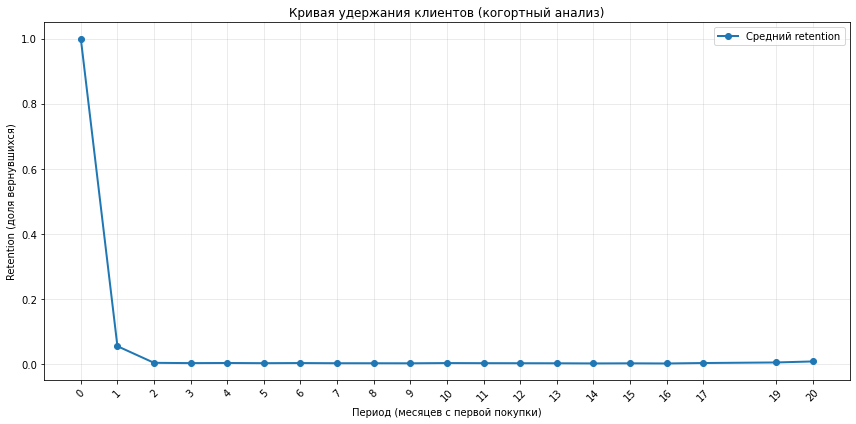

In [22]:
# Усредняем retention по всем когортам для каждого периода
avg_retention = pivot.mean(axis=0)   # среднее по когортам для каждого месяца
med_retention = pivot.median(axis=0) # медианное

# Построение графика
plt.figure(figsize=(12, 6))

# Средняя кривая удержания
plt.plot(avg_retention.index, avg_retention.values, 
         marker='o', linewidth=2, label='Средний retention')

# Настройки осей и заголовка
plt.xlabel('Период (месяцев с первой покупки)')
plt.ylabel('Retention (доля вернувшихся)')
plt.title('Кривая удержания клиентов (когортный анализ)')
plt.legend()
plt.grid(True, alpha=0.3)

# Подписываем каждый месяц
plt.xticks(avg_retention.index, rotation=45)

plt.tight_layout()
plt.show()

###### Фреймворк ICE

Посмотрев с продактом на когортный анализ и метрики, мы решили, что нужно изменить продукт. Метрики необходимо срочно повышать. Вместе с командой мы сформулировали 3 гипотезы: исправить баг процессинга заказов, сократить время до отгрузки заказа, ввести новый способ оплаты. Победила 1 гипотеза: Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен. Эта гипотеза набрала максимальный балл при оценке по фреймворку ICE=Impact×Confidence×Ease. Получилась следующая таблица (ниже): 


In [23]:
import pandas as pd
df_ice = pd.DataFrame(data)
df_ice['ICE'] = df_ice['Impact'] * df_ice['Confidence'] * df_ice['Ease']
df_ice

,Гипотеза,Impact,Confidence,Ease,ICE
0,Исправить баг процессинга заказов,4,8,6,192
1,Сократить время до отгрузки,1,10,4,40
2,Новый способ оплаты,4,5,9,180





Во время A/B-теста для проверки этой гипотезы мы будем отслеживать следующие метрики: 



Целевая метрика:

    Доля доставленных заказов от всех созданных - в отличии от абсолютного показателя, который может быть подвержен влияюнию внешних факторов (например, повышения трафика из-за рекламной кампании), доля доставленных заказов лучше отображает эффективность изменений.
   

Прокси-метрика:

    Доля отменённых заказов от всех созданных. Чувствительна именно к выбранной гипотезе.Доля отмененных заказов должна заметно снизится сразу же после обновления. Снижение этой метрики — опережающий индикатор того, что целевая метрика (Доля доставленных заказов от всех созданных) в будущем тоже вырастет. Реагирует на изменение быстрее, т.к. для оценки доли доставленных заказов нужно ожидать саму доставку, в то время как отмена, скорее всего, будет происходить быстрее, соответсвнно и вывод о конечном статусе заказа за период времени формируется быстрее (напрмиер, неделя, вместо месяца).

Guardrail-метрика:

    Количество обращений в поддержку. Если исправление одного бага приведет к появлению новых, от гипотезы следует отказаться. Продакт-менеджер ставит в приоритет пользовательский опыт.


#### 3. Рекомендации по продукту

Продукт пока не готов к масштабированию. При отсутствии PMF масштабирование кратно увеличит убытки: приток новых пользователей будет быстро «сгорать» из-за неудовлетворительного первого опыта и низкого возврата.

Дополнительный трафик лишь умножит число отменённых заказов и недовольных клиентов, нанося репутационный ущерб.

Экономика такого роста разрушительна:стоимость привлечения не будет окупаться.

Сначала необходимо устранить фундаментальные проблемы, мешающие естественному удержанию.

Продуктовой команде нужно сфокусироваться в ближайшее время на: 
1. Исправление бага в системе процессинга заказов. 

2. Провести контролируемый A/B-тест с предложенными метриками.

3. При подтверждении эффективности раскатать фичу.

4. Рассмотреть остальные гипотезы и сформировать новые.

# ПРЕЗЕНТАЦИЯ

https://disk.yandex.ru/client/disk/%D0%9F%D1%80%D0%B5%D0%B7%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D1%8F